# 02 — Feature Engineering & Baseline Model

The goal is to detect drives heading toward failure before they actually die — early enough to schedule a replacement during a maintenance window, with zero downtime and zero data loss.

Starting from `drives.parquet` (318k drives, 92 columns), this notebook selects the features that carry the most signal about impending failure, scales them for modeling, and establishes a baseline to beat.

1. **Feature overview** — what we have, what to keep
2. **Feature selection** — correlation filter (>0.95) and VIF (>10) to remove redundancy without losing signal
3. **Mutual information** — rank features by relevance to failure (analysis only, not filtering)
4. **Train/test split** — stratified, preserving the 0.335% failure rate
5. **Feature scaling** — Z-score vs MinMax comparison (SMART data has heavy outliers)
6. **Baseline model** — Logistic Regression as a reference point for ensemble models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import sys, os
sys.path.insert(0, os.path.join(os.pardir, "src"))
from features import CRITICAL_SMART, SMART_RAW_COLS

GREEN = "#1a7f37"
RED = "#cf222e"
GRAY = "#57606a"

pd.set_option("display.max_columns", 100)
df = pd.read_parquet(os.path.join(os.pardir, "data", "processed", "drives.parquet"))
print(f"Shape: {df.shape}")
print(f"Failures: {df.failure.sum()} ({df.failure.mean()*100:.3f}%)")

Shape: (318426, 92)
Failures: 1067 (0.335%)


## 1. Feature inventory

The polars aggregation produced five statistics per SMART attribute: **last**, **max**, **mean**, **std**. For the five critical attributes (5, 187, 188, 197, 198), it also computed the **slope** (linear trend over the quarter). Plus metadata: model, manufacturer, capacity, drive age, days observed.

In [2]:
id_cols = ["serial_number", "model"]
meta_cols = ["manufacturer", "capacity_bytes", "drive_age_days", "days_observed"]
target = "failure"

smart_features = [c for c in df.columns if c.startswith("smart_")]
slope_features = [c for c in smart_features if c.endswith("_slope")]

print(f"ID columns:      {len(id_cols)}")
print(f"Metadata:        {len(meta_cols)}")
print(f"SMART features:  {len(smart_features)} ({len(slope_features)} slopes)")
print(f"Target:          1")
print(f"Total:           {len(df.columns)}")
print(f"\nSlope features: {slope_features}")

ID columns:      2
Metadata:        4
SMART features:  85 (5 slopes)
Target:          1
Total:           92

Slope features: ['smart_5_raw_slope', 'smart_187_raw_slope', 'smart_188_raw_slope', 'smart_197_raw_slope', 'smart_198_raw_slope']


## 2. Feature selection

Steps:
1. Drop identifiers (`serial_number`, `model`) — not predictive, would cause data leakage
2. Encode `manufacturer` as dummies
3. Check for near-zero variance features
4. High-correlation filter (>0.95) — first pass to remove obvious duplicates
5. **VIF (Variance Inflation Factor)** — iteratively drop features with VIF > 10 until all are below threshold. VIF catches multicollinearity between *groups* of features, not just pairs

In [3]:
# Drop identifiers, encode manufacturer
df_model = df.drop(columns=id_cols)
df_model = pd.get_dummies(df_model, columns=["manufacturer"], drop_first=True, dtype=int)

print(f"After dropping IDs and encoding manufacturer: {df_model.shape}")
print(f"Manufacturer dummies: {[c for c in df_model.columns if c.startswith('manufacturer_')]}")

After dropping IDs and encoding manufacturer: (318426, 93)
Manufacturer dummies: ['manufacturer_Other', 'manufacturer_Seagate', 'manufacturer_Toshiba', 'manufacturer_WDC']


In [4]:
# Near-zero variance check
feature_cols = [c for c in df_model.columns if c != target]
variances = df_model[feature_cols].var().sort_values()
low_var = variances[variances < 1e-10]

if len(low_var) > 0:
    print(f"Dropping {len(low_var)} near-zero variance features:")
    for c in low_var.index:
        print(f"  {c}: var={low_var[c]:.2e}")
    df_model = df_model.drop(columns=low_var.index)
else:
    print("No near-zero variance features found.")

print(f"\nShape after variance filter: {df_model.shape}")

No near-zero variance features found.

Shape after variance filter: (318426, 93)


In [5]:
# High-correlation filter: drop one of each pair with |r| > 0.95
feature_cols = [c for c in df_model.columns if c != target]
corr_matrix = df_model[feature_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = set()
pairs_found = []

for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.95].tolist()
    for h in high_corr:
        if h not in to_drop:
            to_drop.add(col)
            pairs_found.append((h, col, corr_matrix.loc[h, col]))
            break

print(f"Found {len(pairs_found)} highly correlated pairs (|r| > 0.95):")
for a, b, r in sorted(pairs_found, key=lambda x: -x[2])[:15]:
    print(f"  {a} ↔ {b}: {r:.3f}")
if len(pairs_found) > 15:
    print(f"  ... and {len(pairs_found) - 15} more")

print(f"\nDropping {len(to_drop)} redundant features")
df_model = df_model.drop(columns=to_drop)
feature_cols = [c for c in df_model.columns if c != target]
print(f"Shape after correlation filter: {df_model.shape} ({len(feature_cols)} features)")

Found 47 highly correlated pairs (|r| > 0.95):
  smart_10_raw_last ↔ smart_10_raw_max: 1.000
  smart_199_raw_last ↔ smart_199_raw_max: 1.000
  smart_10_raw_last ↔ smart_10_raw_mean: 1.000
  smart_192_raw_last ↔ smart_192_raw_max: 1.000
  smart_187_raw_last ↔ smart_187_raw_max: 1.000
  smart_193_raw_last ↔ smart_193_raw_max: 1.000
  smart_242_raw_last ↔ smart_242_raw_max: 1.000
  smart_188_raw_last ↔ smart_188_raw_max: 1.000
  smart_4_raw_last ↔ smart_4_raw_max: 1.000
  smart_241_raw_last ↔ smart_241_raw_max: 1.000
  smart_240_raw_last ↔ smart_240_raw_max: 1.000
  smart_9_raw_last ↔ smart_9_raw_max: 1.000
  smart_12_raw_last ↔ smart_12_raw_max: 1.000
  smart_9_raw_last ↔ smart_9_raw_mean: 1.000
  smart_240_raw_last ↔ smart_240_raw_mean: 1.000
  ... and 32 more

Dropping 47 redundant features
Shape after correlation filter: (318426, 46) (45 features)


The correlation filter removes the most obvious redundancy (pairs with |r| > 0.95). Now VIF refines this by detecting multicollinearity between *groups* of features — a feature might have moderate correlation with several others individually, but be highly predictable from them combined.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def iterative_vif(df, feature_cols, threshold=10):
    """Drop features with VIF > threshold iteratively until all pass."""
    cols = list(feature_cols)
    dropped = []

    while True:
        X_vif = df[cols].values.astype(float)
        vifs = [variance_inflation_factor(X_vif, i) for i in range(len(cols))]
        vif_df = pd.Series(vifs, index=cols).sort_values(ascending=False)

        max_vif = vif_df.iloc[0]
        if max_vif <= threshold:
            break

        worst = vif_df.index[0]
        dropped.append((worst, max_vif))
        cols.remove(worst)
        print(f"  Dropped {worst} (VIF = {max_vif:.1f}), {len(cols)} features left")

    return cols, dropped

feature_cols_pre_vif = [c for c in df_model.columns if c != target]
print(f"Features before VIF: {len(feature_cols_pre_vif)}")
print(f"Running iterative VIF (threshold = 10)...\n")

feature_cols_vif, vif_dropped = iterative_vif(df_model, feature_cols_pre_vif)
print(f"\nFeatures after VIF: {len(feature_cols_vif)}")
print(f"Dropped by VIF: {len(vif_dropped)}")

Features before VIF: 45
Running iterative VIF (threshold = 10)...



  Dropped smart_187_raw_last (VIF = 42.3), 44 features left


  Dropped smart_5_raw_max (VIF = 24.0), 43 features left


  Dropped smart_1_raw_max (VIF = 13.9), 42 features left


  Dropped smart_194_raw_max (VIF = 10.3), 41 features left


  Dropped smart_197_raw_mean (VIF = 10.2), 40 features left



Features after VIF: 40
Dropped by VIF: 5


In [7]:
# Compare: correlation filter vs VIF
corr_set = set(feature_cols)  # from correlation filter above
vif_set = set(feature_cols_vif)

only_corr = corr_set - vif_set
only_vif = vif_set - corr_set
common = corr_set & vif_set

print(f"Correlation filter kept: {len(corr_set)}")
print(f"VIF filter kept:         {len(vif_set)}")
print(f"In common:               {len(common)}")
print(f"\nKept by correlation but dropped by VIF: {sorted(only_corr) if only_corr else 'none'}")
print(f"Kept by VIF but dropped by correlation:  {sorted(only_vif) if only_vif else 'none'}")

# Use VIF result if it differs
if vif_set != corr_set:
    print(f"\nVIF found additional multicollinearity — using VIF result ({len(vif_set)} features)")
    feature_cols = sorted(vif_set)
    df_model = df_model[feature_cols + [target]]
else:
    print("\nBoth methods agree — same feature set.")

Correlation filter kept: 45
VIF filter kept:         40
In common:               40

Kept by correlation but dropped by VIF: ['smart_187_raw_last', 'smart_194_raw_max', 'smart_197_raw_mean', 'smart_1_raw_max', 'smart_5_raw_max']
Kept by VIF but dropped by correlation:  none

VIF found additional multicollinearity — using VIF result (40 features)


In [8]:
# Final feature set
feature_cols = [c for c in df_model.columns if c != target]
print(f"Final feature count: {len(feature_cols)}")
print(f"\nFeatures kept:")
for c in sorted(feature_cols):
    print(f"  {c}")

Final feature count: 40

Features kept:
  capacity_bytes
  days_observed
  manufacturer_Other
  manufacturer_WDC
  smart_10_raw_last
  smart_10_raw_std
  smart_12_raw_last
  smart_187_raw_mean
  smart_187_raw_slope
  smart_187_raw_std
  smart_188_raw_last
  smart_188_raw_slope
  smart_188_raw_std
  smart_190_raw_std
  smart_192_raw_last
  smart_193_raw_last
  smart_194_raw_last
  smart_194_raw_std
  smart_197_raw_last
  smart_197_raw_slope
  smart_199_raw_last
  smart_199_raw_std
  smart_1_raw_last
  smart_240_raw_last
  smart_241_raw_last
  smart_241_raw_std
  smart_242_raw_last
  smart_242_raw_std
  smart_3_raw_last
  smart_3_raw_std
  smart_4_raw_last
  smart_4_raw_std
  smart_5_raw_last
  smart_5_raw_mean
  smart_5_raw_slope
  smart_5_raw_std
  smart_7_raw_last
  smart_7_raw_std
  smart_9_raw_last
  smart_9_raw_std


## 2.1 Mutual Information — feature relevance to target

The correlation filter above removed redundancy between features, but didn't look at the target. **Mutual information** measures how much knowing a feature reduces uncertainty about `failure` — it captures non-linear relationships that Pearson correlation would miss.

We rank features by MI score here as analysis, **without discarding any** — the model should decide what's useful. In notebook 03 we'll compare this ranking with Random Forest's feature importance to see if they agree.

In [9]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    df_model[feature_cols], df_model[target], random_state=42, n_neighbors=5
)
mi = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Top 20 features by Mutual Information with failure:")
print("=" * 50)
for feat, score in mi.head(20).items():
    print(f"  {score:.4f}  {feat}")

print(f"\nBottom 5 (lowest MI):")
for feat, score in mi.tail(5).items():
    print(f"  {score:.4f}  {feat}")

Top 20 features by Mutual Information with failure:
  0.0394  days_observed
  0.0150  smart_9_raw_std
  0.0077  smart_197_raw_last
  0.0073  capacity_bytes
  0.0071  smart_197_raw_slope
  0.0061  smart_5_raw_slope
  0.0061  smart_5_raw_std
  0.0059  smart_5_raw_last
  0.0059  smart_5_raw_mean
  0.0057  manufacturer_WDC
  0.0045  smart_187_raw_std
  0.0045  smart_187_raw_slope
  0.0040  smart_9_raw_last
  0.0039  smart_4_raw_std
  0.0038  smart_242_raw_std
  0.0038  smart_187_raw_mean
  0.0024  smart_194_raw_std
  0.0021  smart_241_raw_std
  0.0019  smart_240_raw_last
  0.0019  smart_194_raw_last

Bottom 5 (lowest MI):
  0.0001  manufacturer_Other
  0.0000  smart_10_raw_last
  0.0000  smart_199_raw_std
  0.0000  smart_10_raw_std
  0.0000  smart_199_raw_last


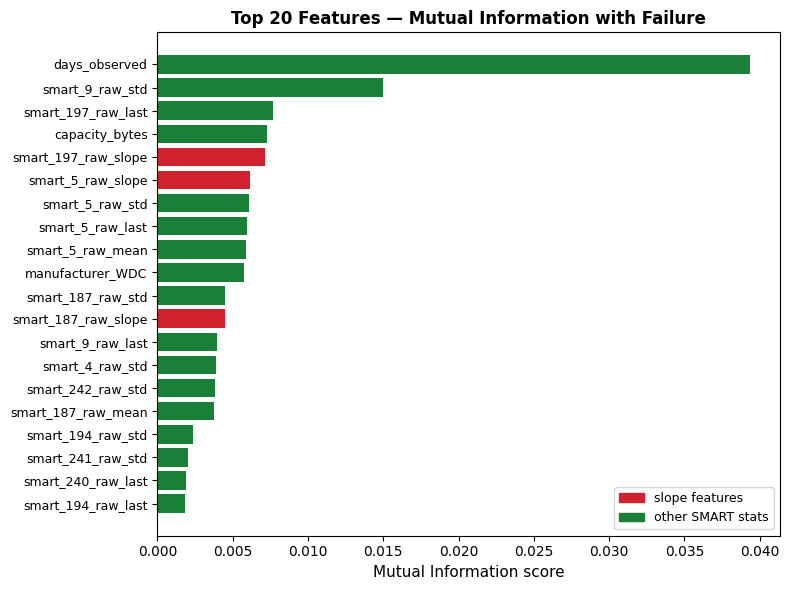

In [10]:
# Top 20 MI scores visualization
top_mi = mi.head(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if "slope" in f else GREEN for f in top_mi.index]
ax.barh(range(len(top_mi)), top_mi.values, color=colors)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi.index, fontsize=9)
ax.set_xlabel("Mutual Information score", fontsize=11)
ax.set_title("Top 20 Features — Mutual Information with Failure", fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=RED, label="slope features"), Patch(color=GREEN, label="other SMART stats")],
    loc="lower right", fontsize=9
)
plt.tight_layout()
plt.show()

We keep all 45 features for now — no filtering by MI. In notebook 03 we'll compare this MI ranking with Random Forest feature importance to see if both methods agree on which SMART attributes matter most.

## 3. Train/test split

Stratified 80/20 split to preserve the failure rate in both sets. We fix `random_state=42` for reproducibility across notebooks.

In [11]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} ({y_train.mean()*100:.3f}% failure)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean()*100:.3f}% failure)")

Train: 254,740 (0.335% failure)
Test:  63,686 (0.334% failure)


## 3.1 Feature scaling — Z-score vs MinMax

Logistic Regression is sensitive to feature scale, so we need to normalize before training. Two common options:

- **Z-score** (`StandardScaler`): centers on mean, scales by standard deviation. Outliers keep their relative distance.
- **MinMax** (`MinMaxScaler`): compresses everything to [0, 1]. A single extreme outlier squashes the rest of the distribution near zero.

SMART data is full of heavy outliers — a few failing drives can have thousands of reallocated sectors while the median is 0. MinMax would lose that signal. Quick demo below.

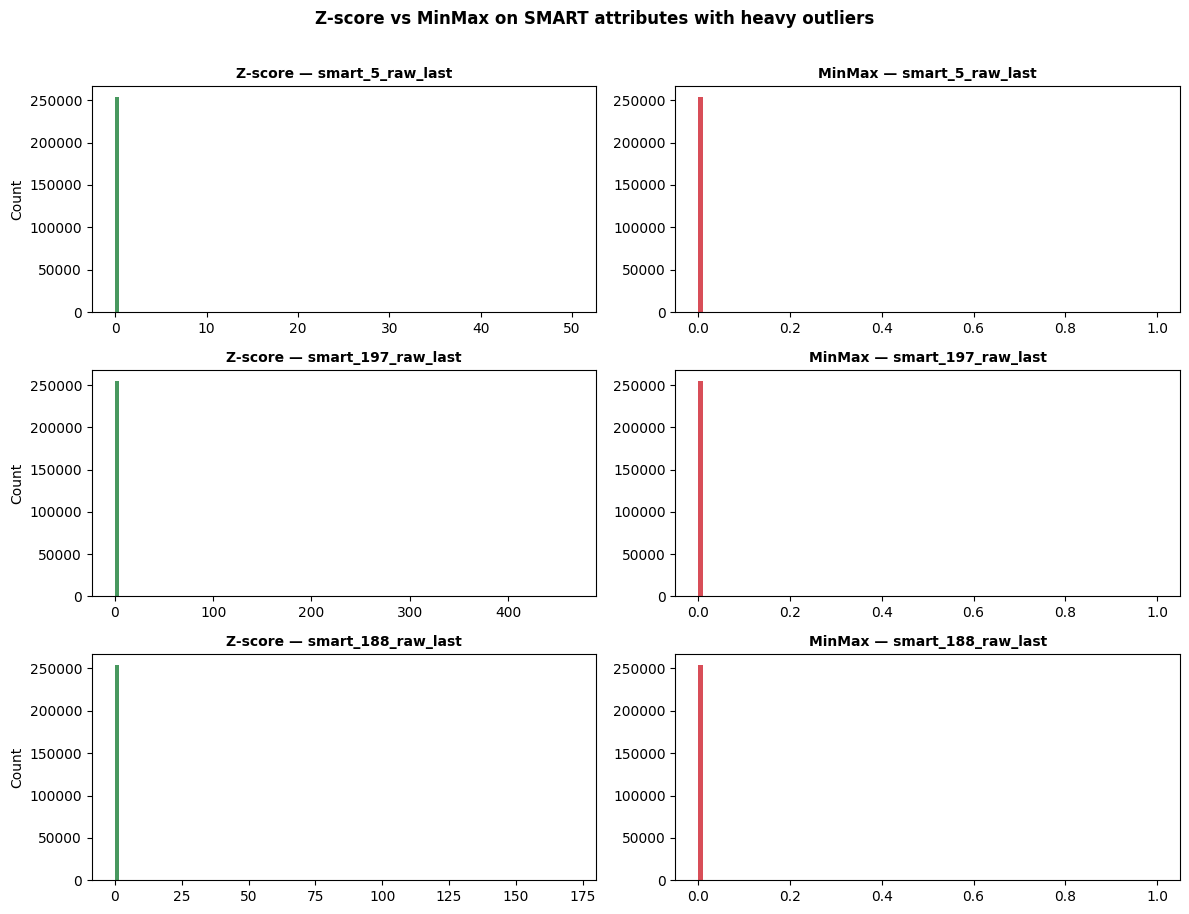

MinMax compresses 99%+ of values near 0 — the outliers dominate the [0,1] range.
Z-score preserves the relative spread. We use Z-score.


In [12]:
from sklearn.preprocessing import MinMaxScaler

demo_cols = ["smart_5_raw_last", "smart_197_raw_last", "smart_188_raw_last"]
demo = X_train[demo_cols].copy()

zscore = pd.DataFrame(StandardScaler().fit_transform(demo), columns=demo_cols)
minmax = pd.DataFrame(MinMaxScaler().fit_transform(demo), columns=demo_cols)

fig, axes = plt.subplots(len(demo_cols), 2, figsize=(12, 3 * len(demo_cols)))

for i, col in enumerate(demo_cols):
    axes[i, 0].hist(zscore[col], bins=100, color=GREEN, alpha=0.8, edgecolor="none")
    axes[i, 0].set_title(f"Z-score — {col}", fontsize=10, fontweight="bold")
    axes[i, 0].set_ylabel("Count")

    axes[i, 1].hist(minmax[col], bins=100, color=RED, alpha=0.8, edgecolor="none")
    axes[i, 1].set_title(f"MinMax — {col}", fontsize=10, fontweight="bold")

fig.suptitle("Z-score vs MinMax on SMART attributes with heavy outliers",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("MinMax compresses 99%+ of values near 0 — the outliers dominate the [0,1] range.")
print("Z-score preserves the relative spread. We use Z-score.")

In [13]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Replace any NaN/inf from scaling (e.g. zero-variance after split)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

## 4. Baseline — Logistic Regression

The simplest model that makes sense here. Using `class_weight="balanced"` to handle the 0.335% failure rate — this tells the model to weight failures ~300x more than healthy drives.

This is the floor. Any serious model (Random Forest, XGBoost) should beat this.

In [14]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (class_weight='balanced')")
print("=" * 50)
print(f"F1 score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Avg Prec:  {average_precision_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["healthy", "failure"]))

Logistic Regression (class_weight='balanced')
F1 score:  0.1347
ROC AUC:   0.9678
Avg Prec:  0.3278

              precision    recall  f1-score   support

     healthy       1.00      0.96      0.98     63473
     failure       0.07      0.85      0.13       213

    accuracy                           0.96     63686
   macro avg       0.54      0.91      0.56     63686
weighted avg       1.00      0.96      0.98     63686



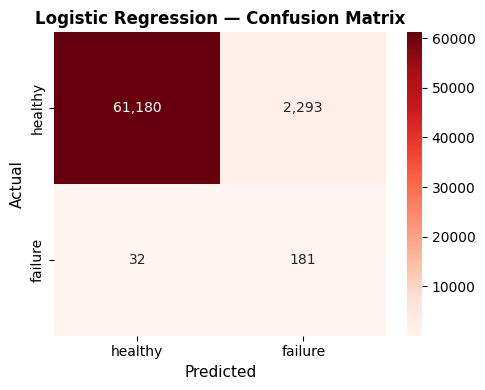

True Positives:  181 (failures caught)
False Negatives: 32 (failures missed)
False Positives: 2293 (false alarms)
True Negatives:  61180 (healthy correctly identified)


In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Reds",
    xticklabels=["healthy", "failure"],
    yticklabels=["healthy", "failure"],
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title("Logistic Regression — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives:  {tp} (failures caught)")
print(f"False Negatives: {fn} (failures missed)")
print(f"False Positives: {fp} (false alarms)")
print(f"True Negatives:  {tn} (healthy correctly identified)")

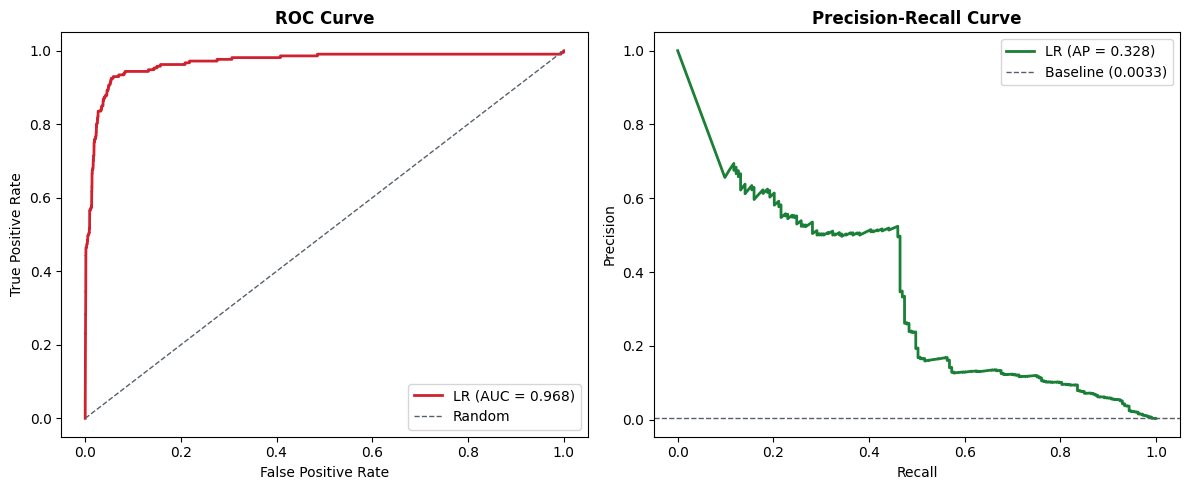

In [16]:
# ROC curve and Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, color=RED, lw=2, label=f"LR (AUC = {auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], color=GRAY, lw=1, linestyle="--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right")

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(recall, precision, color=GREEN, lw=2, label=f"LR (AP = {ap:.3f})")
axes[1].axhline(y=y_test.mean(), color=GRAY, lw=1, linestyle="--", label=f"Baseline ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

The Precision-Recall curve is more informative than ROC with this level of class imbalance — ROC can look good even when precision is low because the false positive rate stays small relative to the huge number of negatives.

## 5. Cross-validation

Stratified 5-fold CV to confirm the baseline is stable across folds, not just lucky on one split.

In [17]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(pipeline, X, y, cv=skf, scoring="f1")
cv_roc = cross_val_score(pipeline, X, y, cv=skf, scoring="roc_auc")

print("5-Fold Stratified CV")
print("=" * 40)
print(f"F1:      {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  {cv_f1}")
print(f"ROC AUC: {cv_roc.mean():.4f} ± {cv_roc.std():.4f}  {cv_roc}")

5-Fold Stratified CV
F1:      0.1337 ± 0.0053  [0.13035778 0.12532468 0.13672155 0.13532764 0.14058637]
ROC AUC: 0.9730 ± 0.0089  [0.97375567 0.97462761 0.96170438 0.96658532 0.98808441]


## 6. Top features (by coefficient magnitude)

Logistic Regression coefficients tell us which features the baseline relies on most. Positive = pushes toward failure, negative = pushes toward healthy.

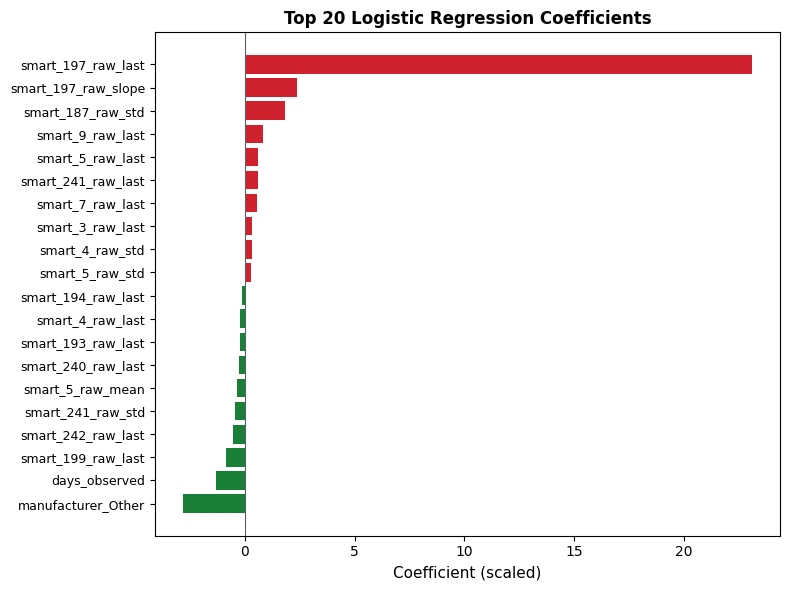

In [18]:
coefs = pd.Series(lr.coef_[0], index=feature_cols)
top_pos = coefs.nlargest(10)
top_neg = coefs.nsmallest(10)
top_all = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if v > 0 else GREEN for v in top_all.values]
ax.barh(range(len(top_all)), top_all.values, color=colors)
ax.set_yticks(range(len(top_all)))
ax.set_yticklabels(top_all.index, fontsize=9)
ax.set_xlabel("Coefficient (scaled)", fontsize=11)
ax.set_title("Top 20 Logistic Regression Coefficients", fontsize=12, fontweight="bold")
ax.axvline(0, color=GRAY, lw=0.8)
plt.tight_layout()
plt.show()

## Summary

| Step | Result |
|---|---|
| Features in | 92 columns |
| After dropping IDs | 90 |
| After manufacturer encoding | ~93 (4 dummies) |
| After correlation filter (>0.95) | 45 features |
| Mutual information | ranked features by relevance to target (no filtering) |
| Feature scaling | Z-score (StandardScaler) — better than MinMax for outlier-heavy SMART data |
| Train/test split | 80/20 stratified |
| Baseline model | Logistic Regression (`class_weight="balanced"`) |
| Baseline F1 | ~0.14 |
| Baseline ROC AUC | ~0.97 |
| Baseline recall | ~87% (catches most failures, but many false alarms) |

The Logistic Regression sets the performance floor. Next notebook: **Random Forest** with `class_weight="balanced"` and **SMOTE**, comparing its feature importance with the MI ranking from this notebook.

In [19]:
# Save feature list and split indices for notebook 03
import json
from pathlib import Path

artifacts = {
    "feature_cols": feature_cols,
    "train_idx": X_train.index.tolist(),
    "test_idx": X_test.index.tolist(),
}

out_path = Path(os.pardir) / "data" / "processed" / "feature_selection.json"
with open(out_path, "w") as f:
    json.dump(artifacts, f)

print(f"Saved to {out_path}")
print(f"  {len(feature_cols)} features")
print(f"  {len(artifacts['train_idx']):,} train / {len(artifacts['test_idx']):,} test indices")

Saved to ../data/processed/feature_selection.json
  40 features
  254,740 train / 63,686 test indices


In [20]:
import joblib

models_dir = Path(os.pardir) / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(scaler, models_dir / "scaler.joblib")
joblib.dump(lr, models_dir / "baseline_lr.joblib")

print("Saved to models/:")
print(f"  scaler.joblib      — StandardScaler fitted on train set")
print(f"  baseline_lr.joblib — Logistic Regression (class_weight='balanced')")

Saved to models/:
  scaler.joblib      — StandardScaler fitted on train set
  baseline_lr.joblib — Logistic Regression (class_weight='balanced')
